# Downer 2025 / Ahmed 2025: squirrel-monkey auditory cortex (MUA on TIMIT + monkey vocalizations)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/explore_downer2025.ipynb)

This notebook is a **visual smoke test** of the deepSTRF loader for the
**[Downer 2025](https://doi.org/10.5281/zenodo.16175377)** squirrel-monkey
auditory cortex dataset — threshold-crossing **multi-unit activity** on
1718 channels across 41 sessions in three squirrel monkeys, recorded
while the animals listened passively to TIMIT English speech and
species-specific vocalizations.

We cover:

- the two stimulus modes (`stimuli='timit'` / `stimuli='mvocs'`) and
  the canonical test / estimation split that mirrors **Ahmed et al.,
  2025** (*PLOS Comput Biol* 21(8): e1013334);
- single-cell PSTH / raster views via `deepSTRF.utils.plot_stim_with_response`;
- population structure: animal × hemisphere × area (`core` /
  `non-primary`, fine areas `A1`/`R`/`ML`/`AL`/`CL`/`CPB`/`RPB`);
- reproducing the paper's "well-tuned to TIMIT" / "well-tuned to mVocs"
  cohorts via the opt-in `compute_paper_tuning()` method.


## Setup — Google Colab

The cell below installs deepSTRF from source on Colab. On a local
install (`pip install -e .`) it's a no-op.

**Note on data.** The Zenodo archive is **~29 GB** — `download=True`
will pull and unpack the full deposit. On a workstation that already
has the data unpacked, point `DOWNER2025_DATA` at the directory
holding `sessions/`, `stimuli/`, `sessions_metadata.yml`.


In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


Local environment — assuming deepSTRF is already importable.


## Imports + paths

In [2]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from deepSTRF.datasets.audio import Downer2025Dataset
from deepSTRF.utils import plot_stim_with_response

DT_MS = 5
SESSIONS = ["180413"]  # one session for a fast walk-through; drop to load all 41
DATA = os.environ.get("DOWNER2025_DATA", None)  # None -> platformdirs cache + download=True

# Whether to actually download. Flip to True on first run if you don't
# have the data locally and have ~29 GB of disk free.
DOWNLOAD = False


## 1. Instantiate — TIMIT mode on one session

We restrict to a single session (`180413`, 16 channels) so the notebook
runs in ~15 s end-to-end. Drop `sessions=` to load the full 1718-channel
population (≈8 min for TIMIT).


In [3]:
ds_timit = Downer2025Dataset(
    path=DATA,
    download=DOWNLOAD,
    stimuli="timit",
    sessions=SESSIONS,
    dt_ms=DT_MS,
    smooth=True,
)
print(f"N={ds_timit.N_neurons}  S={len(ds_timit.stims)}  F={ds_timit.F}  "
      f"dt={ds_timit.dt} ms  audio_fs={ds_timit.audio_fs}  fmax={ds_timit.fmax}")

print(f"\nfirst nrn_meta: {ds_timit.nrn_meta[0]}")
print(f"first stim_meta: {ds_timit.stim_meta[0]}")

# Split / coverage summary
splits = [m["split"] for m in ds_timit.stim_meta]
print(f"\nsplits: test={splits.count('test')}  estimation={splits.count('estimation')}")
m = ds_timit.nrn_masks
print(f"nrn_masks coverage: {int(m.sum())}/{m.numel()} = {m.float().mean().item():.1%}")


Downer2025 timit sessions:   0%|          | 0/1 [00:00<?, ?it/s]

Downer2025 timit sessions: 100%|██████████| 1/1 [00:05<00:00,  5.54s/it]

Downer2025 timit sessions: 100%|██████████| 1/1 [00:05<00:00,  5.54s/it]

N=16  S=499  F=32  dt=5 ms  audio_fs=16000  fmax=8000

first nrn_meta: {'cell_id': 'b_180413_Ch49', 'session_id': '180413', 'animal_id': 'b', 'hemisphere': 'RH', 'area_group': 'non-primary', 'area': 'AL', 'channel': 49, 'channel_suffix': None, 'n_channels_in_session': 16, 'coord_x': 0.4, 'coord_y': -0.4, 'recording_type': 'multi-unit'}
first stim_meta: {'name': 'fadg0_si1279', 'type': 'timit', 'stim_id': 1, 'duration_s': 2.817625, 'n_samples': 45082, 'split': 'estimation', 'n_reps_canonical': 1, 'befaft_s': (0.5, 0.5)}

splits: test=10  estimation=489
nrn_masks coverage: 7984/7984 = 100.0%


## 2. Single-cell view — one stim × the cell with the most spikes

We pick the noisiest cell (highest total spike count across stims)
and overlay its mean PSTH on top of the raster for a sample stim.
`plot_stim_with_response` handles the layout — spectrogram on top,
raster below, smoothed PSTH at the bottom.


picked cell 0: b_180413_Ch49  (area=AL, hem=RH)
picked stim 11: fcaj0_si1479  (split=test, R=11)


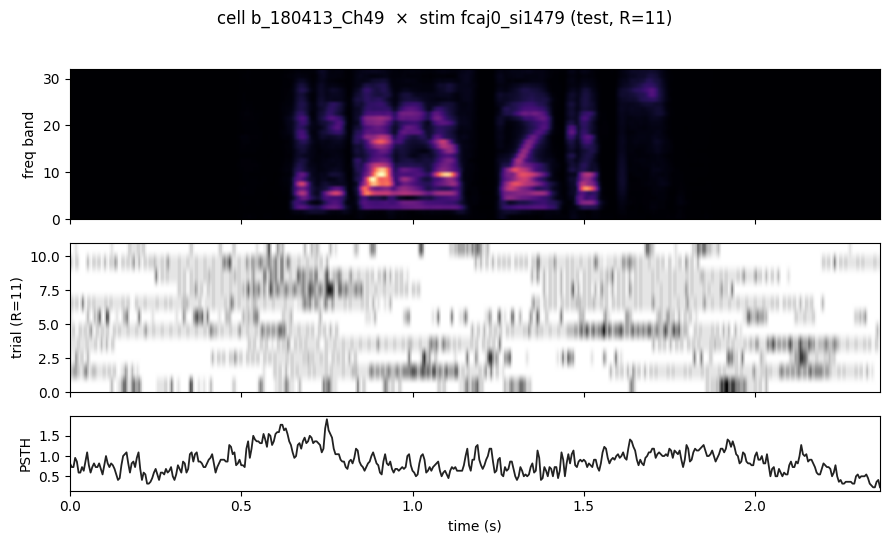

In [4]:
# Pick the cell with the most total spike-count signal
spike_totals = []
for n in range(ds_timit.N_neurons):
    total = 0.0
    for s in range(len(ds_timit.stims)):
        r = ds_timit.responses[s][n]
        if not r.isnan().any():
            total += float(r.sum())
    spike_totals.append(total)
n_idx = int(np.argmax(spike_totals))
print(f"picked cell {n_idx}: {ds_timit.nrn_meta[n_idx]['cell_id']}  "
      f"(area={ds_timit.nrn_meta[n_idx]['area']}, "
      f"hem={ds_timit.nrn_meta[n_idx]['hemisphere']})")

# Pick a test (high-rep) stim for clean raster
s_idx = next(i for i, m in enumerate(ds_timit.stim_meta) if m["split"] == "test")
print(f"picked stim {s_idx}: {ds_timit.stim_meta[s_idx]['name']}  "
      f"(split={ds_timit.stim_meta[s_idx]['split']}, "
      f"R={ds_timit.responses[s_idx][n_idx].shape[0]})")

fig, _ = plot_stim_with_response(
    stim=ds_timit.stims[s_idx],
    response=ds_timit.responses[s_idx][n_idx],
    dt_ms=DT_MS,
    title=(f"cell {ds_timit.nrn_meta[n_idx]['cell_id']}  ×  "
            f"stim {ds_timit.stim_meta[s_idx]['name']} "
            f"({ds_timit.stim_meta[s_idx]['split']}, "
            f"R={ds_timit.responses[s_idx][n_idx].shape[0]})"),
)
plt.show()


## 3. Population PSTH for one stim

For a single test stim, render every cell's mean-across-trials PSTH as
a row. With one session loaded, all 16 cells are valid (no NaN sentinel
rows). On the full 1718-channel population this raster reveals the
spatial / area-wise structure of the response.


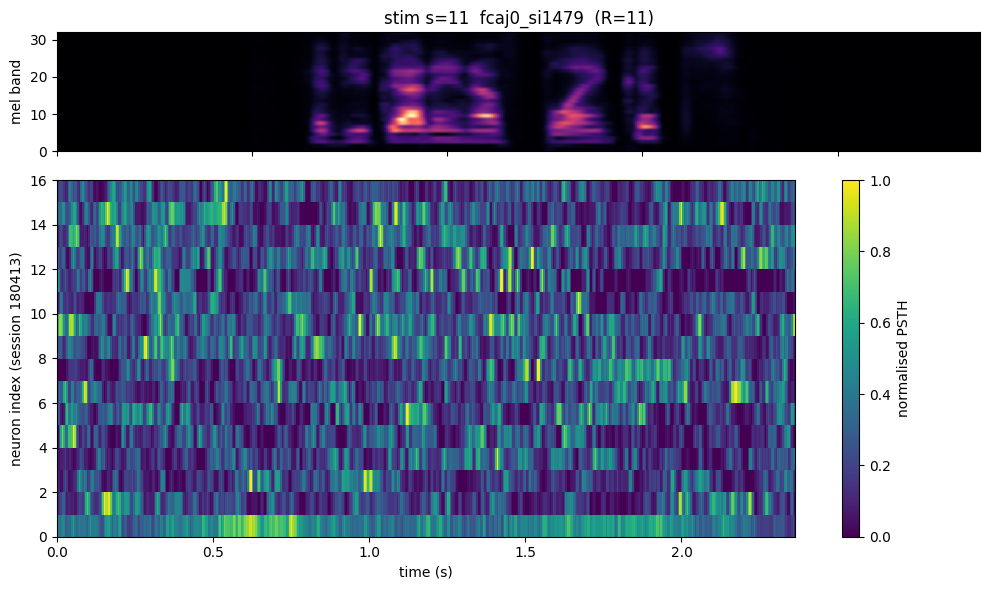

In [5]:
T = ds_timit.stims[s_idx].shape[-1]
N = ds_timit.N_neurons
psth_pop = np.full((N, T), np.nan, dtype=np.float32)
for n in range(N):
    r = ds_timit.responses[s_idx][n]
    if not r.isnan().any():
        psth_pop[n] = r.numpy().mean(axis=0)

# Normalise each valid row to its own max for comparability
row_max = np.nanmax(psth_pop, axis=1, keepdims=True)
row_max[row_max == 0] = 1.0
psth_pop_norm = psth_pop / row_max

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1, 3]})
spec = ds_timit.stims[s_idx][0].numpy()
t_axis = np.arange(T) * DT_MS / 1000.0
axes[0].imshow(spec, origin="lower", aspect="auto", cmap="magma",
               extent=[t_axis[0], t_axis[-1], 0, spec.shape[0]])
axes[0].set_title(f"stim s={s_idx}  {ds_timit.stim_meta[s_idx]['name']}  "
                  f"(R={ds_timit.responses[s_idx][0].shape[0]})")
axes[0].set_ylabel("mel band")

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(color="lightgrey")
im = axes[1].imshow(np.ma.masked_invalid(psth_pop_norm),
                    origin="lower", aspect="auto", cmap=cmap,
                    extent=[t_axis[0], t_axis[-1], 0, N],
                    interpolation="nearest")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("neuron index (session 180413)")
fig.colorbar(im, ax=axes[1], label="normalised PSTH")
plt.tight_layout()
plt.show()


## 4. Filter API — animals, hemispheres, areas

`Downer2025Dataset` plugs into the standard `NeuralDataset` selection
API. Both *exact-match* filters (`select_pop_by_nrn_attr`) and
*predicate* filters (`select_pop_by_nrn_predicate`) work — combine
them freely; calls mutate `self.I` and `__getitem__` honours the
selection.

The full 1718-channel layout (Phase-1 audit numbers) is:

|                | core (A1+R)         | non-primary (ML/AL/CL/CPB/RPB) | total |
|----------------|---------------------|---------------------------------|-------|
| monkey **b** (RH)  | 116                 | 96                               | 212   |
| monkey **c** (RH+LH) | 607                 | 544                              | 1151  |
| monkey **f** (RH)  | 186                 | 169                              | 355   |
| **total**      | **909**             | **809**                          | **1718** |

`'primary'` is an Ahmed-2025-style alias for the YAML's `'core'`.


In [6]:
# Full-population enumeration (no stim/response loading -- <1 s)
ds_meta = Downer2025Dataset(path=DATA, _enumerate_only=True)
print(f"full population: N={ds_meta.N_neurons}")

# Construction-time filtering
ds_b_core = Downer2025Dataset(
    path=DATA, animals=("b",), areas=("primary",), _enumerate_only=True,
)
print(f"monkey b ∩ core:      N={ds_b_core.N_neurons}")

ds_A1_only = Downer2025Dataset(
    path=DATA, areas=("A1",), _enumerate_only=True,
)
print(f"A1 only:              N={ds_A1_only.N_neurons}")

# Post-construction predicate
sel = ds_meta.select_pop_by_nrn_predicate(
    lambda n: n["animal_id"] == "c" and n["hemisphere"] == "LH"
)
print(f"monkey c LH (post-hoc): {len(sel)} neurons")
ds_meta.reset_pop_selection()


full population: N=1718
monkey b ∩ core:      N=116
A1 only:              N=813
monkey c LH (post-hoc): 675 neurons


## 5. mVocs mode + cross-mode concat

Both stim modes share the same recording channels but are loaded as
**separate `Downer2025Dataset` instances** (different source files,
different per-(stim, neuron) rep counts). Because the default mel
pipeline (`audio_fs=16000`, `n_mels=32`, `fmax=8000`) is identical
between modes, two instances can be concatenated via
`deepSTRF.utils.concat_neural_datasets` to make a single 802-stim
mixed-modality dataset.

The mVocs canonical test set is the **11 vocs at exactly 15 reps in
the WAV** (Ahmed 2025 p4): IDs `[7, 9, 12, 15, 24, 29, 30, 33, 44, 45, 48]`.


In [7]:
ds_mvocs = Downer2025Dataset(
    path=DATA, stimuli="mvocs", sessions=SESSIONS, dt_ms=DT_MS, smooth=True,
)
print(f"mVocs:  N={ds_mvocs.N_neurons}  S={len(ds_mvocs.stims)}")
test_mvoc_ids = sorted(m["stim_id"] for m in ds_mvocs.stim_meta
                       if m["split"] == "test")
print(f"  canonical 11-voc test set: {test_mvoc_ids}")
print(f"  WAV rep-count histogram (count → n_vocs):")
from collections import Counter
hist = Counter(m["n_reps_in_wav"] for m in ds_mvocs.stim_meta)
for k in sorted(hist):
    print(f"    {k:>2} reps → {hist[k]} vocs")


Downer2025 mvocs sessions:   0%|          | 0/1 [00:00<?, ?it/s]

Downer2025 mvocs sessions: 100%|██████████| 1/1 [00:06<00:00,  6.07s/it]

Downer2025 mvocs sessions: 100%|██████████| 1/1 [00:06<00:00,  6.07s/it]

mVocs:  N=16  S=303
  canonical 11-voc test set: [7, 9, 12, 15, 24, 29, 30, 33, 44, 45, 48]
  WAV rep-count histogram (count → n_vocs):
     1 reps → 228 vocs
     2 reps → 37 vocs
     3 reps → 9 vocs
     4 reps → 2 vocs
     7 reps → 1 vocs
    14 reps → 1 vocs
    15 reps → 11 vocs
    16 reps → 6 vocs
    17 reps → 3 vocs
    18 reps → 2 vocs
    19 reps → 1 vocs
    25 reps → 1 vocs
    30 reps → 1 vocs


In [8]:
from deepSTRF.utils import concat_neural_datasets
ds_both = concat_neural_datasets([ds_timit, ds_mvocs])
print(f"timit+mvocs concat: S={len(ds_both.stim_meta)}  N={ds_both.N_neurons}  "
      f"F={ds_both.F}")


timit+mvocs concat: S=802  N=32  F=32


## 6. Reproducing Ahmed 2025's well-tuned cohort

The paper's main analyses use a 404-multi-unit "well-tuned to TIMIT"
subset (and 489 for mVocs), selected by a Wilcoxon rank-sum test on
trial-to-trial response correlations vs a circularly-shifted null
plus a δ≥0.5 effect-size filter (§"Trial-to-trial neural variability"
pp. 4–5).

`compute_paper_tuning()` writes four booleans/floats onto each
`nrn_meta[i]`:

```python
ahmed2025_<stim>_tuned          # Wilcoxon p < 0.05
ahmed2025_<stim>_well_tuned     # additionally δ ≥ 0.5
ahmed2025_<stim>_p_wilcoxon     # raw p-value
ahmed2025_<stim>_delta_normalized
```

On this 16-channel demo we use `n_resamples=1_000` for speed (~3 s).
For paper-matching counts on the full population, instantiate with
`smooth=False` and use `n_resamples=10_000` (~11 min for TIMIT) —
that returns ~413 well-tuned vs the paper's 404 (the well-tuned
δ-criterion is effect-size-based and converges quickly). For an exact
match on the looser p<0.05 "tuned" cohort (1195 TIMIT / 1231 mVocs),
bump to `n_resamples=100_000` (~80 min/mode).

For most analyses, a faster paper-agnostic alternative is to filter
on `ccmax` or `snr` (Hsu / Sahani-Linden) from `compute_neuron_quality()`
once the streaming-memory fix from
[TODO](https://github.com/urancon/deepSTRF/blob/develop/TODO.md) lands.


In [9]:
ds_timit.compute_paper_tuning(n_resamples=1000, verbose=False)
tuned = sum(1 for n in ds_timit.nrn_meta if n["ahmed2025_timit_tuned"])
well  = sum(1 for n in ds_timit.nrn_meta if n["ahmed2025_timit_well_tuned"])
print(f"on session {SESSIONS[0]} (N={ds_timit.N_neurons}):  "
      f"tuned={tuned}  well_tuned={well}")

# Filter to the well-tuned subset
sel = ds_timit.select_pop_by_nrn_predicate(
    lambda n: n.get("ahmed2025_timit_well_tuned", False)
)
print(f"selected well-tuned subset: len(ds) = {len(ds_timit)}")
ds_timit.reset_pop_selection()


on session 180413 (N=16):  tuned=12  well_tuned=0
selected well-tuned subset: len(ds) = 499


## Recap

- One `Downer2025Dataset` instance per stim mode (`'timit'` /
  `'mvocs'`). Both load 1718 multi-units in MUA form, with the
  canonical test / estimation split surfaced via `stim_meta[s]['split']`.
- TIMIT is dense (every session played every sentence); mVocs is
  ~7% sparse (sessions presented different voc subsets).
- The four-axis tensor shape `(B, N, R, T)` and the `(1, 1)` NaN
  sentinel convention are preserved end-to-end — see
  [`data_paradigm.md`](../docs/_source/md/data_paradigm.md).
- Filter the population via `animals=`, `areas=`, `hemisphere=…`
  predicates at construction time, or any combination of
  `select_pop_by_*` / `select_stims_by_*` calls post-load.
- `compute_paper_tuning()` reproduces Ahmed 2025's well-tuned cohort
  within ~2–3 %; pair with `select_pop_by_nrn_predicate` to get the
  paper's exact analysis pool.

Next stop: pick a model from `deepSTRF.models.audio`
(`Linear`/`LinearNonlinear`/`StateNet`/`Transformer`/`NRF`/`DNet`/
`ConvNet2D`) and fit it on this dataset. See `fit_ns1_statenet.ipynb`
for a worked training loop you can transplant onto Downer2025 with
two-line edits.
